# EfficientAD: Teacher-Student Anomaly Detection
Fast & efficient anomaly detection without k-NN memory banks

In [16]:
# ============================================================
# Cell 1: Setup and Imports
# ============================================================

import os
import gc
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
from sklearn.metrics import confusion_matrix, f1_score

warnings.filterwarnings('ignore')

# Clear any existing GPU memory
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

# Set seeds for reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name()}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"   Currently allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    torch.cuda.empty_cache()
    gc.collect()

🔧 Device: cuda
   GPU: NVIDIA GeForce RTX 3060 Laptop GPU
   Memory: 6.1 GB
   Currently allocated: 0.10 GB


In [17]:
# ============================================================
# Cell 2: Configuration
# ============================================================

@dataclass
class EfficientADConfig:
    """Configuration for EfficientAD training."""
    
    # Data paths
    data_root: str = "./mvtec_anomaly_detection"
    
    # Image settings - reduced for 6GB GPU
    img_size: int = 224
    
    # Training settings - small batch size for 6GB GPU
    batch_size: int = 4
    num_workers: int = 4
    
    # Architecture
    backbone: str = "efficientnet_b4"  # Teacher backbone
    feature_layers: Tuple[int, ...] = (1, 2, 3)  # Layers to extract features from
    student_channels: int = 256
    
    # Training hyperparameters
    epochs: int = 100
    lr: float = 1e-4
    weight_decay: float = 1e-5
    warmup_epochs: int = 5
    patience: int = 15
    
    # Loss weights
    reconstruction_weight: float = 1.0
    consistency_weight: float = 0.1
    
    # Inference
    use_tta: bool = True  # Test-time augmentation
    anomaly_threshold: float = 0.5
    
    # Outputs
    save_dir: str = "./efficientad_outputs"
    save_heatmaps: bool = True


config = EfficientADConfig()
print(f"📊 EfficientAD Configuration:")
for field in config.__dataclass_fields__:
    print(f"   {field}: {getattr(config, field)}")

📊 EfficientAD Configuration:
   data_root: ./mvtec_anomaly_detection
   img_size: 224
   batch_size: 4
   num_workers: 4
   backbone: efficientnet_b4
   feature_layers: (1, 2, 3)
   student_channels: 256
   epochs: 100
   lr: 0.0001
   weight_decay: 1e-05
   warmup_epochs: 5
   patience: 15
   reconstruction_weight: 1.0
   consistency_weight: 0.1
   use_tta: True
   anomaly_threshold: 0.5
   save_dir: ./efficientad_outputs
   save_heatmaps: True


In [18]:
# ============================================================
# Cell 3: MVTec AD Dataset
# ============================================================

class MVTecADDataset(Dataset):
    """MVTec Anomaly Detection dataset."""
    
    def __init__(
        self,
        root: str,
        category: str,
        split: str = "train",
        img_size: int = 256,
        transform: Optional[transforms.Compose] = None
    ):
        self.root = Path(root)
        self.category = category
        self.split = split
        self.img_size = img_size
        
        # Default transform
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                )
            ])
        else:
            self.transform = transform
        
        # Mask transform (no normalization)
        self.mask_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor()
        ])
        
        # Load image paths
        self.samples = self._load_samples()
    
    def _load_samples(self) -> List[Tuple[Path, int, Optional[Path]]]:
        """Load image paths and labels."""
        samples = []
        split_dir = self.root / self.category / self.split
        
        if self.split == "train":
            # Training: only good samples
            good_dir = split_dir / "good"
            if good_dir.exists():
                for img_path in sorted(good_dir.glob("*.png")):
                    samples.append((img_path, 0, None))  # 0 = normal
        else:
            # Testing: good + defective samples
            for defect_dir in sorted(split_dir.iterdir()):
                if defect_dir.is_dir():
                    is_anomaly = 0 if defect_dir.name == "good" else 1
                    
                    for img_path in sorted(defect_dir.glob("*.png")):
                        # Find corresponding mask
                        mask_path = None
                        if is_anomaly:
                            mask_dir = self.root / self.category / "ground_truth" / defect_dir.name
                            mask_name = img_path.stem + "_mask.png"
                            potential_mask = mask_dir / mask_name
                            if potential_mask.exists():
                                mask_path = potential_mask
                        
                        samples.append((img_path, is_anomaly, mask_path))
        
        return samples
    
    def __len__(self) -> int:
        return len(self.samples)
    
    def __getitem__(self, idx: int) -> Dict:
        img_path, label, mask_path = self.samples[idx]
        
        # Load and transform image
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        
        # Load mask if exists
        if mask_path is not None:
            mask = Image.open(mask_path).convert("L")
            mask = self.mask_transform(mask)
            mask = (mask > 0.5).float()  # Binarize
        else:
            mask = torch.zeros(1, self.img_size, self.img_size)
        
        return {
            "image": image,
            "label": label,
            "mask": mask,
            "path": str(img_path)
        }


# Check available categories
mvtec_path = Path(config.data_root)
if mvtec_path.exists():
    categories = sorted([d.name for d in mvtec_path.iterdir() if d.is_dir() and not d.name.startswith('.')])
    print(f"\n📁 Available MVTec AD categories ({len(categories)}):")
    for i, cat in enumerate(categories, 1):
        print(f"   {i:2d}. {cat}")
else:
    print(f"⚠️ MVTec AD not found at {config.data_root}")
    categories = []


📁 Available MVTec AD categories (15):
    1. bottle
    2. cable
    3. capsule
    4. carpet
    5. grid
    6. hazelnut
    7. leather
    8. metal_nut
    9. pill
   10. screw
   11. tile
   12. toothbrush
   13. transistor
   14. wood
   15. zipper


In [19]:
# ============================================================
# Cell 4: Teacher Network (Frozen Pretrained)
# ============================================================

class TeacherNetwork(nn.Module):
    """
    Teacher Network for EfficientAD.
    
    Uses a pretrained EfficientNet-B4 (frozen) to extract multi-scale features.
    The teacher provides the target features that the student learns to reconstruct.
    """
    
    def __init__(
        self, 
        backbone: str = "efficientnet_b4",
        feature_layers: Tuple[int, ...] = (1, 2, 3),
        img_size: int = 256
    ):
        super().__init__()
        
        self.feature_layers = feature_layers
        
        # Load pretrained backbone
        if backbone == "efficientnet_b4":
            base = models.efficientnet_b4(
                weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1
            )
            self.features = base.features
        else:
            base = models.resnet50(
                weights=models.ResNet50_Weights.IMAGENET1K_V1
            )
            self.features = nn.Sequential(
                base.conv1, base.bn1, base.relu, base.maxpool,
                base.layer1, base.layer2, base.layer3, base.layer4
            )
        
        # Freeze all parameters
        for param in self.parameters():
            param.requires_grad = False
        
        self.eval()  # Always in eval mode
        
        # Dynamically detect feature channels by running a forward pass
        self._detect_feature_channels(img_size)
    
    def _detect_feature_channels(self, img_size: int):
        """Detect actual feature channels by running a forward pass."""
        self.feature_channels = {}
        with torch.no_grad():
            x = torch.randn(1, 3, img_size, img_size)
            for i, layer in enumerate(self.features):
                x = layer(x)
                if i in self.feature_layers:
                    self.feature_channels[f"layer{i}"] = x.shape[1]
    
    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """Extract multi-scale features."""
        features = {}
        
        for i, layer in enumerate(self.features):
            x = layer(x)
            if i in self.feature_layers:
                features[f"layer{i}"] = x
        
        return features
    
    def get_feature_channels(self) -> Dict[str, int]:
        """Get output channels for each extracted layer."""
        return self.feature_channels


# Create teacher and verify
teacher = TeacherNetwork(
    backbone=config.backbone,
    feature_layers=config.feature_layers,
    img_size=config.img_size
).to(device)

# Test forward pass
dummy_input = torch.randn(1, 3, config.img_size, config.img_size).to(device)
with torch.no_grad():
    features = teacher(dummy_input)

print(f"\n✓ Teacher Network ({config.backbone}):")
print(f"   Feature channels: {teacher.get_feature_channels()}")
print(f"   Output shapes:")
for name, feat in features.items():
    print(f"      {name}: {feat.shape}")


✓ Teacher Network (efficientnet_b4):
   Feature channels: {'layer1': 24, 'layer2': 32, 'layer3': 56}
   Output shapes:
      layer1: torch.Size([1, 24, 112, 112])
      layer2: torch.Size([1, 32, 56, 56])
      layer3: torch.Size([1, 56, 28, 28])


In [20]:
# ============================================================
# Cell 5: Student Network (Corrected encoder_out=80)
# ============================================================

class StudentNetwork(nn.Module):
    """
    Student Network for EfficientAD.
    
    Lightweight network that learns to reconstruct teacher features.
    Discrepancy between teacher and student features indicates anomaly.
    """
    
    def __init__(
        self, 
        teacher_channels: Dict[str, int],
        student_channels: int = 256,
        backbone: str = 'efficientnet_b4'
    ):
        super().__init__()
        
        self.teacher_channels = teacher_channels
        self.student_channels = student_channels
        
        # Shared encoder (lightweight) - Use EfficientNet-B0 for student
        if backbone == 'efficientnet_b4':
            base = models.efficientnet_b0(
                weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
            )
            self.encoder = base.features[:5]  # Use first few stages
            # IMPORTANT: EfficientNet-B0 features[:5] outputs 80 channels, not 40!
            encoder_out = 80
        else:
            base = models.resnet18(
                weights=models.ResNet18_Weights.IMAGENET1K_V1
            )
            self.encoder = nn.Sequential(
                base.conv1, base.bn1, base.relu, base.maxpool,
                base.layer1, base.layer2
            )
            encoder_out = 128
        
        self.encoder_out = encoder_out
        
        # Feature reconstruction heads (one per teacher layer)
        self.reconstruction_heads = nn.ModuleDict()
        
        for name, channels in teacher_channels.items():
            self.reconstruction_heads[name] = nn.Sequential(
                nn.Conv2d(encoder_out, student_channels, 3, padding=1),
                nn.BatchNorm2d(student_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(student_channels, student_channels, 3, padding=1),
                nn.BatchNorm2d(student_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(student_channels, channels, 1),  # Match teacher channels
            )
    
    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """Reconstruct teacher features."""
        # Encode input
        encoded = self.encoder(x)
        
        # Reconstruct each teacher feature
        outputs = {}
        for name, head in self.reconstruction_heads.items():
            outputs[name] = head(encoded)
        
        return outputs


# Create student network
teacher_channels = teacher.get_feature_channels()
student = StudentNetwork(
    teacher_channels=teacher_channels,
    student_channels=config.student_channels,
    backbone=config.backbone
).to(device)

total_params = sum(p.numel() for p in student.parameters())
trainable_params = sum(p.numel() for p in student.parameters() if p.requires_grad)

print(f"\n✓ Student Network:")
print(f"   Encoder output channels: {student.encoder_out}")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

# Test forward pass
with torch.no_grad():
    student_features = student(dummy_input)
    print(f"   Output shapes:")
    for name, feat in student_features.items():
        print(f"      {name}: {feat.shape}")


✓ Student Network:
   Encoder output channels: 80
   Total parameters: 2,664,484
   Trainable parameters: 2,664,484
   Output shapes:
      layer1: torch.Size([1, 24, 14, 14])
      layer2: torch.Size([1, 32, 14, 14])
      layer3: torch.Size([1, 56, 14, 14])


In [21]:
# ============================================================
# Cell 6: EfficientAD Model (Combining Teacher-Student)
# ============================================================

class EfficientAD(nn.Module):
    """
    Complete EfficientAD model combining teacher and student networks.
    
    Key insight: Anomalies are detected by comparing teacher (pretrained, frozen)
    and student (trained to reconstruct normal patterns) feature outputs.
    """
    
    def __init__(
        self,
        teacher: TeacherNetwork,
        student: StudentNetwork,
        img_size: int = 256
    ):
        super().__init__()
        
        self.teacher = teacher
        self.student = student
        self.img_size = img_size
        
        # Freeze teacher
        for param in self.teacher.parameters():
            param.requires_grad = False
        self.teacher.eval()
    
    def forward(
        self, 
        x: torch.Tensor,
        return_features: bool = False
    ) -> Dict[str, torch.Tensor]:
        """
        Forward pass computing teacher-student discrepancy.
        
        Args:
            x: Input images [B, 3, H, W]
            return_features: Whether to return intermediate features
            
        Returns:
            Dictionary with anomaly_map and optionally features
        """
        # Get teacher features (frozen)
        with torch.no_grad():
            teacher_features = self.teacher(x)
        
        # Get student reconstructions
        student_features = self.student(x)
        
        # Compute per-layer anomaly maps
        layer_maps = []
        
        for name in teacher_features.keys():
            t_feat = teacher_features[name]
            s_feat = student_features[name]
            
            # Ensure same spatial size
            if t_feat.shape[2:] != s_feat.shape[2:]:
                s_feat = F.interpolate(
                    s_feat, 
                    size=t_feat.shape[2:],
                    mode='bilinear',
                    align_corners=False
                )
            
            # Compute MSE anomaly map (per-pixel squared difference)
            anomaly = (t_feat - s_feat).pow(2).mean(dim=1, keepdim=True)
            
            # Upsample to image size
            anomaly = F.interpolate(
                anomaly,
                size=(self.img_size, self.img_size),
                mode='bilinear',
                align_corners=False
            )
            
            layer_maps.append(anomaly)
        
        # Combine layer maps (average)
        anomaly_map = torch.stack(layer_maps, dim=0).mean(dim=0)
        
        output = {"anomaly_map": anomaly_map}
        
        if return_features:
            output["teacher_features"] = teacher_features
            output["student_features"] = student_features
        
        return output
    
    def compute_anomaly_score(self, x: torch.Tensor) -> torch.Tensor:
        """Compute image-level anomaly score."""
        output = self.forward(x)
        # Max pooling over spatial dimensions for image-level score
        anomaly_score = output["anomaly_map"].flatten(1).max(dim=1)[0]
        return anomaly_score


# Create EfficientAD model
model = EfficientAD(
    teacher=teacher,
    student=student,
    img_size=config.img_size
).to(device)

print(f"\n✓ EfficientAD Model created")

# Test complete forward pass
with torch.no_grad():
    output = model(dummy_input, return_features=True)
    print(f"   Anomaly map shape: {output['anomaly_map'].shape}")
    print(f"   Anomaly score: {model.compute_anomaly_score(dummy_input).item():.6f}")


✓ EfficientAD Model created
   Anomaly map shape: torch.Size([1, 1, 224, 224])
   Anomaly score: 2100.501221


In [ ]:
# ============================================================
# Cell 7: Loss Functions
# ============================================================

class EfficientADLoss(nn.Module):
    """
    Loss function for EfficientAD training.
    
    Combines:
    1. Feature reconstruction loss (MSE between teacher and student features)
    2. Multi-scale consistency loss
    """
    
    def __init__(
        self,
        reconstruction_weight: float = 1.0,
        consistency_weight: float = 0.1
    ):
        super().__init__()
        self.reconstruction_weight = reconstruction_weight
        self.consistency_weight = consistency_weight
    
    def forward(
        self,
        teacher_features: Dict[str, torch.Tensor],
        student_features: Dict[str, torch.Tensor]
    ) -> Dict[str, torch.Tensor]:
        """
        Compute loss.
        
        Args:
            teacher_features: Features from teacher network
            student_features: Reconstructed features from student
            
        Returns:
            Dictionary with loss components
        """
        reconstruction_loss = 0.0
        consistency_loss = 0.0
        
        prev_loss = None
        
        for name in teacher_features.keys():
            t_feat = teacher_features[name]
            s_feat = student_features[name]
            
            # Ensure same spatial size
            if t_feat.shape[2:] != s_feat.shape[2:]:You are an expert in industrial anomaly detection and PyTorch.

Implement EfficientAD for the MVTec AD dataset following the original EfficientAD paper design, optimized for fast inference and high accuracy.

REQUIREMENTS:
1. Dataset
   - Support MVTec AD structure (category-wise folders).
   - Train ONLY on normal images.
   - Use both image-level and pixel-level evaluation.
   - Support defect masks if available.

2. Model Architecture
   - Use a pretrained CNN backbone (ResNet-18 or EfficientNet-B4).
   - Extract multi-scale feature maps from intermediate layers.
   - Implement EfficientAD teacher–student framework:
     - Teacher network frozen (pretrained).
     - Student network learns to mimic teacher feature distributions.
   - Use lightweight convolutional heads for efficiency.
   - No k-NN or memory bank at inference time.

3. Training
   - Train student using:
     - Feature reconstruction loss (L2 / cosine).
     - Spatial consistency loss if applicable.
   - Use only normal samples for training.
   - Include data augmentation (flip, rotation, color jitter).
   - Implement early stopping and learning rate scheduling.

4. Inference
   - Compute anomaly score as feature discrepancy between teacher and student.
   - Generate:
     - Image-level anomaly score.
     - Pixel-level anomaly heatmap.
   - Normalize anomaly scores per category.

5. Evaluation
   - Compute:
     - Image-level AUROC.
     - Pixel-level AUROC.
     - PRO score (if masks exist).
   - Provide optional test-time augmentation (TTA).
   - Print confusion matrix and precision/recall.

6. Performance
   - Optimize for fast inference:
     - Single forward pass.
     - No heavy post-processing.
   - Support GPU acceleration.

7. Code Quality
   - Modular folder structure:
       datasets/
       models/
       train.py
       evaluate.py
       utils/
       configs/
   - Clear docstrings and comments.
   - Configurable via YAML or argparse.
   - Reproducible (seed control).

8. Output
   - Save best model checkpoints.
   - Save anomaly heatmaps for visualization.
   - Log metrics per epoch.

Do NOT implement PatchCore, PaDiM, or k-NN based methods.
Focus strictly on EfficientAD.

The implementation must be faithful, efficient, and suitable for research benchmarking on MVTec AD.

                s_feat = F.interpolate(
                    s_feat,
                    size=t_feat.shape[2:],
                    mode='bilinear',
                    align_corners=False
                )
            
            # Reconstruction loss (cosine similarity + L2)
            # Normalize features
            t_norm = F.normalize(t_feat, p=2, dim=1)
            s_norm = F.normalize(s_feat, p=2, dim=1)
            
            # Cosine similarity loss
            cosine_loss = 1 - (t_norm * s_norm).sum(dim=1).mean()
            
            # L2 loss
            l2_loss = F.mse_loss(s_feat, t_feat)
            
            layer_loss = cosine_loss + l2_loss
            reconstruction_loss += layer_loss
            
            # Multi-scale consistency (gradual refinement)
            if prev_loss is not None:
                consistency_loss += (layer_loss - prev_loss).abs()
            prev_loss = layer_loss.detach()
        
        # Normalize by number of layers
        num_layers = len(teacher_features)
        reconstruction_loss = reconstruction_loss / num_layers
        consistency_loss = consistency_loss / max(1, num_layers - 1)
        
        # Total loss
        total_loss = (
            self.reconstruction_weight * reconstruction_loss +
            self.consistency_weight * consistency_loss
        )
        
        return {
            "total": total_loss,
            "reconstruction": reconstruction_loss,
            "consistency": consistency_loss
        }


# Create loss function
criterion = EfficientADLoss(
    reconstruction_weight=config.reconstruction_weight,
    consistency_weight=config.consistency_weight
)

print(f"\n✓ Loss function created")
print(f"   Reconstruction weight: {config.reconstruction_weight}")
print(f"   Consistency weight: {config.consistency_weight}")


✓ Loss function created
   Reconstruction weight: 1.0
   Consistency weight: 0.1


In [23]:
# ============================================================
# Cell 8: Training Function
# ============================================================

def train_efficientad(
    model: EfficientAD,
    train_loader: DataLoader,
    val_loader: Optional[DataLoader],
    config: EfficientADConfig,
    category: str
) -> Dict:
    """
    Train EfficientAD model.
    
    Args:
        model: EfficientAD model
        train_loader: Training data loader
        val_loader: Validation data loader (test set for MVTec)
        config: Training configuration
        category: Category name
        
    Returns:
        Training history dictionary
    """
    # Setup optimizer
    optimizer = torch.optim.AdamW(
        model.student.parameters(),
        lr=config.lr,
        weight_decay=config.weight_decay
    )
    
    # Learning rate scheduler with warmup
    def lr_lambda(epoch):
        if epoch < config.warmup_epochs:
            return (epoch + 1) / config.warmup_epochs
        return 0.5 * (1 + np.cos(np.pi * (epoch - config.warmup_epochs) / (config.epochs - config.warmup_epochs)))
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    
    # Loss function
    criterion = EfficientADLoss(
        reconstruction_weight=config.reconstruction_weight,
        consistency_weight=config.consistency_weight
    )
    
    # Training history
    history = {
        "train_loss": [],
        "val_auroc": [],
        "best_auroc": 0.0,
        "best_epoch": 0
    }
    
    # Early stopping
    patience_counter = 0
    
    print(f"\n🚀 Training EfficientAD for '{category}'")
    print(f"   Epochs: {config.epochs}")
    print(f"   Batch size: {config.batch_size}")
    print(f"   Learning rate: {config.lr}")
    print("-" * 50)
    
    for epoch in range(config.epochs):
        # Training
        model.student.train()
        train_losses = []
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.epochs}")
        
        for batch in pbar:
            images = batch["image"].to(device)
            
            # Forward pass
            output = model(images, return_features=True)
            
            # Compute loss
            losses = criterion(
                output["teacher_features"],
                output["student_features"]
            )
            
            # Backward pass
            optimizer.zero_grad()
            losses["total"].backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.student.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_losses.append(losses["total"].item())
            pbar.set_postfix({
                "loss": f"{losses['total'].item():.4f}",
                "lr": f"{scheduler.get_last_lr()[0]:.6f}"
            })
        
        scheduler.step()
        
        avg_train_loss = np.mean(train_losses)
        history["train_loss"].append(avg_train_loss)
        
        # Validation
        if val_loader is not None:
            val_results = evaluate_efficientad(model, val_loader)
            val_auroc = val_results["image_auroc"]
            history["val_auroc"].append(val_auroc)
            
            print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, "
                  f"Val AUROC={val_auroc:.4f}")
            
            # Save best model
            if val_auroc > history["best_auroc"]:
                history["best_auroc"] = val_auroc
                history["best_epoch"] = epoch + 1
                patience_counter = 0
                
                # Save checkpoint
                save_path = Path(config.save_dir) / category
                save_path.mkdir(parents=True, exist_ok=True)
                torch.save({
                    "epoch": epoch + 1,
                    "student_state_dict": model.student.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "auroc": val_auroc
                }, save_path / "best_model.pth")
            else:
                patience_counter += 1
                
            # Early stopping
            if patience_counter >= config.patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        else:
            print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}")
    
    print("-" * 50)
    print(f"✓ Training complete!")
    print(f"   Best AUROC: {history['best_auroc']:.4f} (Epoch {history['best_epoch']})")
    
    return history


print("✓ Training function defined")

✓ Training function defined


In [24]:
# ============================================================
# Cell 9: Evaluation Function
# ============================================================

@torch.no_grad()
def evaluate_efficientad(
    model: EfficientAD,
    test_loader: DataLoader,
    use_tta: bool = False
) -> Dict:
    """
    Evaluate EfficientAD model.
    
    Args:
        model: Trained EfficientAD model
        test_loader: Test data loader
        use_tta: Whether to use test-time augmentation
        
    Returns:
        Evaluation metrics dictionary
    """
    model.eval()
    
    all_labels = []
    all_scores = []
    all_masks = []
    all_anomaly_maps = []
    
    for batch in tqdm(test_loader, desc="Evaluating"):
        images = batch["image"].to(device)
        labels = batch["label"].numpy()
        masks = batch["mask"].numpy()
        
        # Forward pass
        if use_tta:
            # Test-time augmentation: horizontal flip
            output1 = model(images)
            output2 = model(torch.flip(images, dims=[3]))
            output2["anomaly_map"] = torch.flip(output2["anomaly_map"], dims=[3])
            
            anomaly_map = (output1["anomaly_map"] + output2["anomaly_map"]) / 2
        else:
            output = model(images)
            anomaly_map = output["anomaly_map"]
        
        # Image-level score (max of anomaly map)
        scores = anomaly_map.flatten(1).max(dim=1)[0].cpu().numpy()
        
        all_labels.extend(labels)
        all_scores.extend(scores)
        all_masks.append(masks)
        all_anomaly_maps.append(anomaly_map.cpu().numpy())
    
    # Convert to arrays
    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)
    all_masks = np.concatenate(all_masks, axis=0)
    all_anomaly_maps = np.concatenate(all_anomaly_maps, axis=0)
    
    # Image-level AUROC
    image_auroc = roc_auc_score(all_labels, all_scores)
    
    # Pixel-level AUROC (only on anomalous images)
    anomaly_mask = all_labels == 1
    if anomaly_mask.sum() > 0:
        pixel_labels = all_masks[anomaly_mask].flatten()
        pixel_scores = all_anomaly_maps[anomaly_mask].flatten()
        
        # Only compute if both classes present
        if len(np.unique(pixel_labels)) > 1:
            pixel_auroc = roc_auc_score(pixel_labels, pixel_scores)
        else:
            pixel_auroc = 0.0
    else:
        pixel_auroc = 0.0
    
    # Optimal threshold (Youden's J statistic)
    fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    # Predictions at optimal threshold
    predictions = (all_scores >= optimal_threshold).astype(int)
    
    # F1 score
    f1 = f1_score(all_labels, predictions)
    
    return {
        "image_auroc": image_auroc,
        "pixel_auroc": pixel_auroc,
        "optimal_threshold": optimal_threshold,
        "f1_score": f1,
        "scores": all_scores,
        "labels": all_labels,
        "anomaly_maps": all_anomaly_maps
    }


print("✓ Evaluation function defined")

✓ Evaluation function defined


In [25]:
# ============================================================
# Cell 10: Train on Single Category
# ============================================================

# Clear GPU memory first
import gc
if 'model' in dir():
    del model
if 'teacher' in dir():
    del teacher
if 'student' in dir():
    del student
if 'dummy_input' in dir():
    del dummy_input
gc.collect()
torch.cuda.empty_cache()

print(f"GPU Memory before training: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

# Choose category to train on
category = "bottle"  # Change this to train on different categories

print(f"\n{'='*60}")
print(f"Training EfficientAD on: {category}")
print(f"{'='*60}")

# Create datasets
train_dataset = MVTecADDataset(
    root=config.data_root,
    category=category,
    split="train",
    img_size=config.img_size
)

test_dataset = MVTecADDataset(
    root=config.data_root,
    category=category,
    split="test",
    img_size=config.img_size
)

print(f"   Training samples: {len(train_dataset)}")
print(f"   Test samples: {len(test_dataset)}")

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=True
)

# Re-create model (fresh student for new category)
teacher = TeacherNetwork(
    backbone=config.backbone,
    feature_layers=config.feature_layers,
    img_size=config.img_size
).to(device)

student = StudentNetwork(
    teacher_channels=teacher.get_feature_channels(),
    student_channels=config.student_channels,
    backbone=config.backbone
).to(device)

model = EfficientAD(
    teacher=teacher,
    student=student,
    img_size=config.img_size
).to(device)

print(f"GPU Memory after model creation: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

# Train model
history = train_efficientad(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    config=config,
    category=category
)

# Final evaluation
final_results = evaluate_efficientad(model, test_loader, use_tta=config.use_tta)
print(f"\n📊 Final Results for '{category}':")
print(f"   Image-level AUROC: {final_results['image_auroc']:.4f}")
print(f"   Pixel-level AUROC: {final_results['pixel_auroc']:.4f}")
print(f"   F1 Score: {final_results['f1_score']:.4f}")

GPU Memory before training: 0.10 GB

Training EfficientAD on: bottle
   Training samples: 209
   Test samples: 83
GPU Memory after model creation: 0.18 GB

🚀 Training EfficientAD for 'bottle'
   Epochs: 100
   Batch size: 4
   Learning rate: 0.0001
--------------------------------------------------


Evaluating: 100%|██████████| 21/21 [00:01<00:00, 13.46it/s]


Epoch 1: Train Loss=323.4028, Val AUROC=0.6817


Evaluating: 100%|██████████| 21/21 [00:01<00:00, 14.92it/s]


Epoch 2: Train Loss=314.0257, Val AUROC=0.7016


...

Epoch 42: Train Loss=129.5687, Val AUROC=0.7968


Evaluating: 100%|██████████| 21/21 [00:01<00:00, 10.81it/s]


Epoch 43: Train Loss=128.6916, Val AUROC=0.7952
Early stopping at epoch 43
--------------------------------------------------
✓ Training complete!
   Best AUROC: 0.8206 (Epoch 28)


Evaluating: 100%|██████████| 21/21 [00:02<00:00,  9.55it/s]



📊 Final Results for 'bottle':
   Image-level AUROC: 0.8198
   Pixel-level AUROC: 0.7144
   F1 Score: 0.7778



🎨 Visualizing Results...
   Saved visualization to ./efficientad_outputs/bottle_results.png


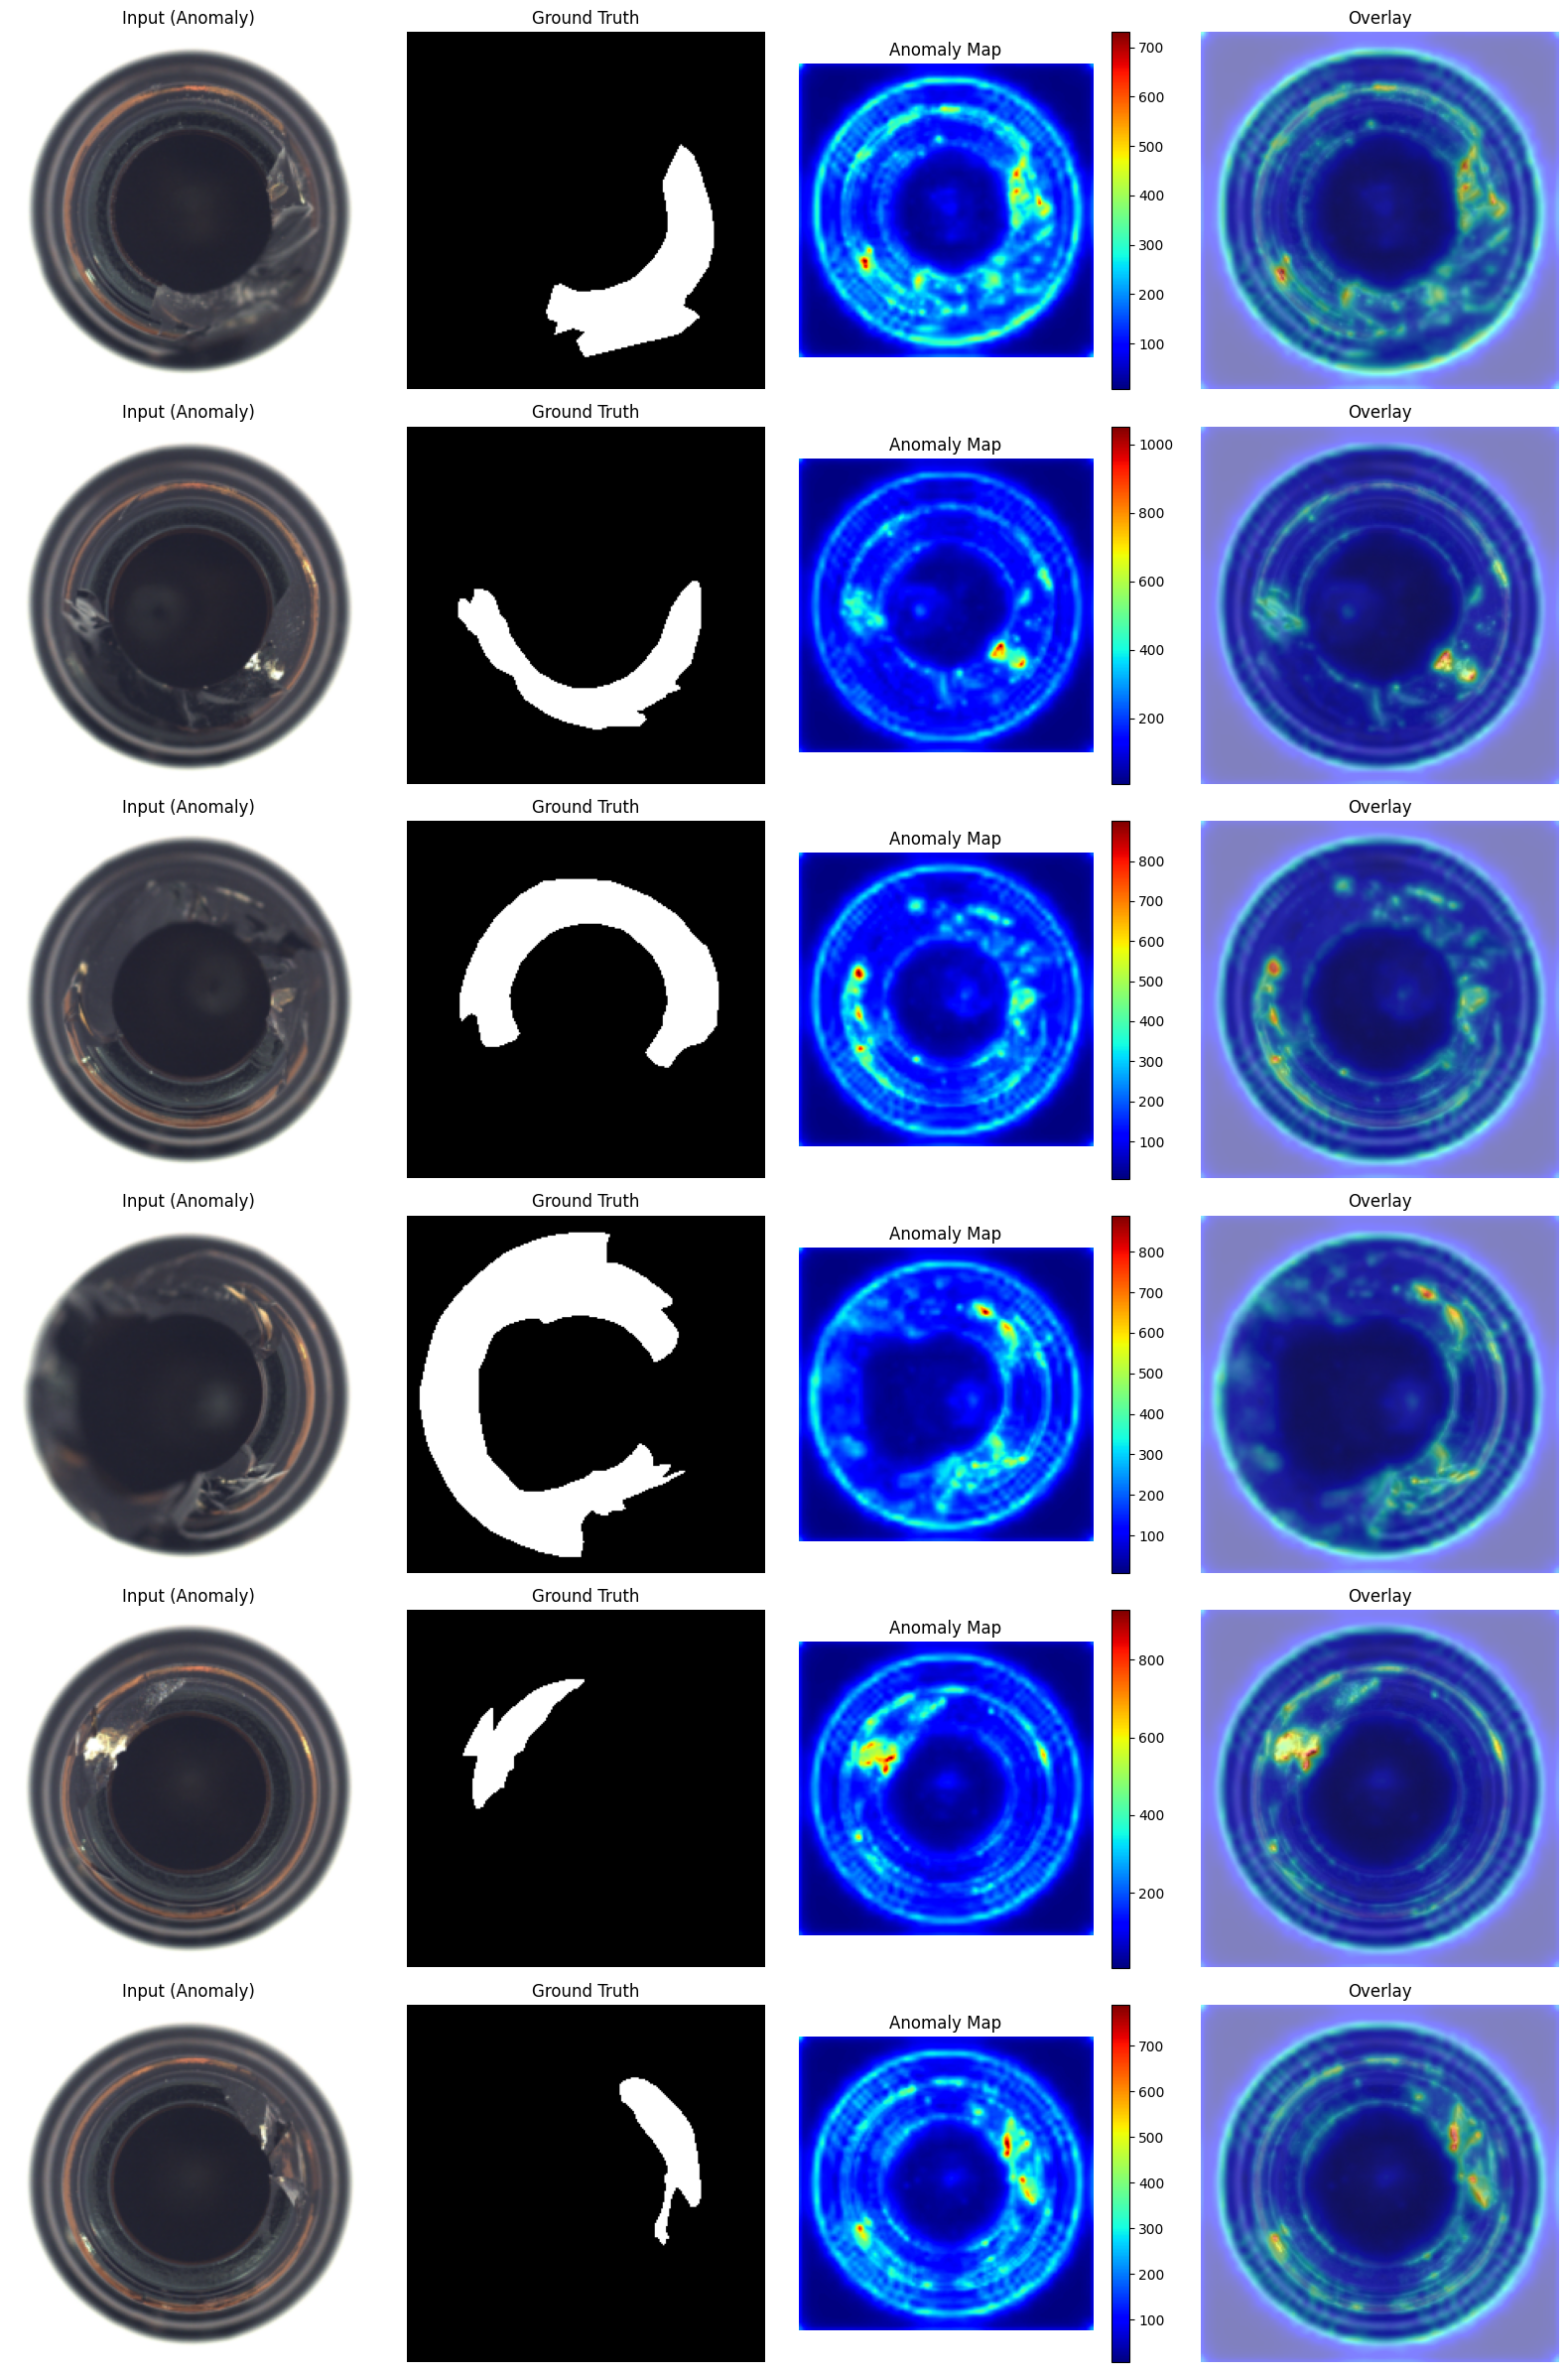

In [26]:
# ============================================================
# Cell 11: Visualization
# ============================================================

def visualize_results(
    model: EfficientAD,
    test_loader: DataLoader,
    num_samples: int = 8,
    save_path: Optional[str] = None
):
    """Visualize anomaly detection results."""
    model.eval()
    
    # Get some samples
    samples = []
    for batch in test_loader:
        for i in range(len(batch["image"])):
            samples.append({
                "image": batch["image"][i],
                "label": batch["label"][i],
                "mask": batch["mask"][i],
                "path": batch["path"][i]
            })
            if len(samples) >= num_samples:
                break
        if len(samples) >= num_samples:
            break
    
    # Create figure
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    # Mean and std for unnormalization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    for i, sample in enumerate(samples):
        image = sample["image"].unsqueeze(0).to(device)
        label = sample["label"]
        mask = sample["mask"].numpy()
        
        # Get anomaly map
        with torch.no_grad():
            output = model(image)
        anomaly_map = output["anomaly_map"][0, 0].cpu().numpy()
        
        # Unnormalize image
        img = sample["image"] * std + mean
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        # Plot original image
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Input ({'Anomaly' if label else 'Normal'})")
        axes[i, 0].axis("off")
        
        # Plot ground truth mask
        axes[i, 1].imshow(mask[0], cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")
        
        # Plot anomaly map
        im = axes[i, 2].imshow(anomaly_map, cmap="jet")
        axes[i, 2].set_title("Anomaly Map")
        axes[i, 2].axis("off")
        plt.colorbar(im, ax=axes[i, 2])
        
        # Plot overlay
        axes[i, 3].imshow(img)
        axes[i, 3].imshow(anomaly_map, cmap="jet", alpha=0.5)
        axes[i, 3].set_title("Overlay")
        axes[i, 3].axis("off")
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"   Saved visualization to {save_path}")
    
    plt.show()


# Visualize results
print("\n🎨 Visualizing Results...")
visualize_results(
    model=model,
    test_loader=test_loader,
    num_samples=6,
    save_path=f"{config.save_dir}/{category}_results.png"
)

In [27]:
# ============================================================
# Cell 12: Train on All Categories (Optional)
# ============================================================

def train_all_categories(config: EfficientADConfig, categories: List[str]) -> Dict:
    """Train EfficientAD on all MVTec AD categories."""
    
    all_results = {}
    
    for cat_idx, category in enumerate(categories, 1):
        print(f"\n{'='*60}")
        print(f"[{cat_idx}/{len(categories)}] Training on: {category}")
        print(f"{'='*60}")
        
        # Create datasets
        train_dataset = MVTecADDataset(
            root=config.data_root,
            category=category,
            split="train",
            img_size=config.img_size
        )
        
        test_dataset = MVTecADDataset(
            root=config.data_root,
            category=category,
            split="test",
            img_size=config.img_size
        )
        
        train_loader = DataLoader(
            train_dataset,
            batch_size=config.batch_size,
            shuffle=True,
            num_workers=config.num_workers,
            pin_memory=True
        )
        
        test_loader = DataLoader(
            test_dataset,
            batch_size=config.batch_size,
            shuffle=False,
            num_workers=config.num_workers,
            pin_memory=True
        )
        
        # Create fresh model
        teacher = TeacherNetwork(
            backbone=config.backbone,
            feature_layers=config.feature_layers,
            img_size=config.img_size
        ).to(device)
        
        student = StudentNetwork(
            teacher_channels=teacher.get_feature_channels(),
            student_channels=config.student_channels,
            backbone=config.backbone
        ).to(device)
        
        model = EfficientAD(
            teacher=teacher,
            student=student,
            img_size=config.img_size
        ).to(device)
        
        # Train
        history = train_efficientad(
            model=model,
            train_loader=train_loader,
            val_loader=test_loader,
            config=config,
            category=category
        )
        
        # Final evaluation
        results = evaluate_efficientad(model, test_loader, use_tta=config.use_tta)
        
        all_results[category] = {
            "image_auroc": results["image_auroc"],
            "pixel_auroc": results["pixel_auroc"],
            "f1_score": results["f1_score"],
            "best_epoch": history["best_epoch"]
        }
        
        # Clear GPU memory
        del model, teacher, student
        torch.cuda.empty_cache()
        gc.collect()
    
    # Print summary
    print("\n" + "="*60)
    print("📊 SUMMARY: All Categories")
    print("="*60)
    print(f"{'Category':<15} {'Image AUROC':>12} {'Pixel AUROC':>12} {'F1 Score':>10}")
    print("-"*60)
    
    image_aurocs = []
    pixel_aurocs = []
    
    for category, results in all_results.items():
        print(f"{category:<15} {results['image_auroc']:>12.4f} "
              f"{results['pixel_auroc']:>12.4f} {results['f1_score']:>10.4f}")
        image_aurocs.append(results['image_auroc'])
        pixel_aurocs.append(results['pixel_auroc'])
    
    print("-"*60)
    print(f"{'Mean':<15} {np.mean(image_aurocs):>12.4f} "
          f"{np.mean(pixel_aurocs):>12.4f}")
    
    return all_results


# Uncomment to train on all categories:
# all_results = train_all_categories(config, categories)

print("\n✅ EfficientAD implementation complete!")
print("   To train on all categories, uncomment the last line in this cell.")


✅ EfficientAD implementation complete!
   To train on all categories, uncomment the last line in this cell.
